# Machine Learning Model Development

The objective of this notebook is to train and evaluate multiple classical machine learning algorithms for sentiment classification using the feature representations developed in the previous notebook.

Each model will be trained on TF-IDF features and evaluated using multiple performance metrics. The best-performing model will be selected based on its overall generalization performance and will serve as the baseline for comparison with deep learning and transformer-based models in subsequent notebooks.

In [52]:
import joblib
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [46]:
# Load all artifacts
X_train_tfidf      = joblib.load("artifacts/X_train_tfidf.pkl")
X_test_tfidf       = joblib.load("artifacts/X_test_tfidf.pkl")
X_train_tfidf_sel  = joblib.load("artifacts/X_train_tfidf_sel.pkl")
X_test_tfidf_sel   = joblib.load("artifacts/X_test_tfidf_sel.pkl")
X_train_tfidf_svd  = joblib.load("artifacts/X_train_tfidf_svd.pkl")
X_test_tfidf_svd   = joblib.load("artifacts/X_test_tfidf_svd.pkl")
X_train_hybrid     = joblib.load("artifacts/X_train_hybrid.pkl")
X_test_hybrid      = joblib.load("artifacts/X_test_hybrid.pkl")

y_train = joblib.load("artifacts/y_train.pkl")
y_test  = joblib.load("artifacts/y_test.pkl")

# Print shapes
print("=" * 80)
print("Feature Engineering Data Shapes")
print("=" * 80)
print(f"Training Samples : {X_train_tfidf.shape[0]}")
print(f"Testing Samples  : {X_test_tfidf.shape[0]}")
print("-" * 80)
print(f"Original TF-IDF  : {X_train_tfidf.shape}")
print(f"TF-IDF Selected  : {X_train_tfidf_sel.shape}")
print(f"TF-IDF SVD       : {X_train_tfidf_svd.shape}")
print(f"Hybrid Features  : {X_train_hybrid.shape}")
print("-" * 80)
print(f"Labels (train)   : {y_train.shape}")
print(f"Labels (test)    : {y_test.shape}")
print("=" * 80)


Feature Engineering Data Shapes
Training Samples : 539618
Testing Samples  : 134905
--------------------------------------------------------------------------------
Original TF-IDF  : (539618, 10000)
TF-IDF Selected  : (539618, 5000)
TF-IDF SVD       : (539618, 300)
Hybrid Features  : (539618, 5003)
--------------------------------------------------------------------------------
Labels (train)   : (539618,)
Labels (test)    : (134905,)


In [53]:
# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)  
print("Encoded:", set(y_train_enc))  

Classes: ['Negative' 'Neutral' 'Positive']
Encoded: {0, 1, 2}


In [6]:
# Define models
models = {

    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=2.0,
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        C=1.5,
        loss="squared_hinge",
        dual=False,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        device_type="gpu",
        random_state=42,
        verbosity=-1
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )

}

# Define feature sets
feature_sets = {
    "TF-IDF Original": (X_train_tfidf, X_test_tfidf),
    "TF-IDF Selected": (X_train_tfidf_sel, X_test_tfidf_sel),
    "TF-IDF SVD": (X_train_tfidf_svd, X_test_tfidf_svd),
    "Hybrid": (X_train_hybrid, X_test_hybrid)
}

In [7]:
def train_model(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start
    return model, training_time

def predict_model(model, X_test):
    start = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start
    return y_pred, prediction_time
    
def calculate_metrics(y_true, y_pred):
    metrics = {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted"), 4),
        "Recall": round(recall_score(y_true, y_pred, average="weighted"), 4),
        "F1 Score": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro"), 4)
    }
    return metrics
    
def run_experiment(model, X_train, X_test, y_train, y_test):
    # Train the model
    trained_model, train_time = train_model(model, X_train, y_train)

    # Predict on test data
    y_pred, predict_time = predict_model(trained_model, X_test)

    # Calculate metrics
    metrics = calculate_metrics(y_test, y_pred)
    metrics["Execution Time (sec)"] = round(train_time + predict_time, 2)

    return trained_model, y_pred, metrics

In [8]:
# Store everything related to each experiment
experiments = {}
results = []

for feature_name, (X_train, X_test) in feature_sets.items():
    print("=" * 80)
    print(f"Feature Set: {feature_name}")
    print("=" * 80)

    for model_name, model in models.items():
        print(f"Training {model_name}...")

        # Run experiment
        trained_model, y_pred, metrics = run_experiment(
            model,
            X_train,
            X_test,
            y_train_enc,
            y_test_enc
        )

        # Add metadata
        metrics["Feature Set"] = feature_name
        metrics["Algorithm"] = model_name
        
        # Collect results
        results.append(metrics)
        experiments[(feature_name, model_name)] = {
            "model": trained_model,
            "prediction": y_pred,
            "metrics": metrics,
            "feature_train": X_train,
            "feature_test": X_test
        }

        # Print summary
        print(
            f"✓ Accuracy: {metrics['Accuracy']:.4f} "
            f"| F1: {metrics['F1 Score']:.4f}"
        )

    print()


Feature Set: TF-IDF Original
Training Logistic Regression...
✓ Accuracy: 0.7963 | F1: 0.8154
Training Linear SVM...
✓ Accuracy: 0.8659 | F1: 0.8681
Training LightGBM...
✓ Accuracy: 0.8757 | F1: 0.8635
Training XGBoost...
✓ Accuracy: 0.0857 | F1: 0.0219

Feature Set: TF-IDF Selected
Training Logistic Regression...
✓ Accuracy: 0.8163 | F1: 0.8402
Training Linear SVM...
✓ Accuracy: 0.8656 | F1: 0.8675
Training LightGBM...
✓ Accuracy: 0.8750 | F1: 0.8627
Training XGBoost...
✓ Accuracy: 0.5132 | F1: 0.4935

Feature Set: TF-IDF SVD
Training Logistic Regression...
✓ Accuracy: 0.7794 | F1: 0.8077
Training Linear SVM...
✓ Accuracy: 0.8422 | F1: 0.8416
Training LightGBM...
✓ Accuracy: 0.8577 | F1: 0.8406
Training XGBoost...
✓ Accuracy: 0.8561 | F1: 0.8381

Feature Set: Hybrid
Training Logistic Regression...
✓ Accuracy: 0.7440 | F1: 0.7754
Training Linear SVM...
✓ Accuracy: 0.8657 | F1: 0.8676
Training LightGBM...
✓ Accuracy: 0.8755 | F1: 0.8634
Training XGBoost...
✓ Accuracy: 0.1032 | F1: 0.0545

In [9]:
results_df = (
    pd.DataFrame(results)
      .sort_values(
          by=["F1 Score", "Accuracy"],
          ascending=False
      )
      .reset_index(drop=True)
)
results_df

,Accuracy,Precision,Recall,F1 Score,Macro F1,Execution Time (sec),Feature Set,Algorithm
0,0.8659,0.8708,0.8659,0.8681,0.7252,60.13,TF-IDF Original,Linear SVM
1,0.8657,0.8700,0.8657,0.8676,0.7254,67.34,Hybrid,Linear SVM
2,0.8656,0.8698,0.8656,0.8675,0.7250,49.45,TF-IDF Selected,Linear SVM
3,0.8757,0.8619,0.8757,0.8635,0.7051,825.94,TF-IDF Original,LightGBM
4,0.8755,0.8616,0.8755,0.8634,0.7045,641.38,Hybrid,LightGBM
5,0.8750,0.8610,0.8750,0.8627,0.7036,512.71,TF-IDF Selected,LightGBM
6,0.8422,0.8423,0.8422,0.8416,0.6884,133.62,TF-IDF SVD,Linear SVM
7,0.8577,0.8441,0.8577,0.8406,0.6683,230.18,TF-IDF SVD,LightGBM
8,0.8163,0.8816,0.8163,0.8402,0.6959,2425.53,TF-IDF Selected,Logistic Regression
9,0.8561,0.8432,0.8561,0.8381,0.6635,119.98,TF-IDF SVD,XGBoost


## Model Performance Summary

A comprehensive comparison was conducted using four classical machine learning algorithms across multiple feature representations, including Original TF-IDF, Selected TF-IDF (Chi-Square), TF-IDF with TruncatedSVD, and Hybrid Features.

### Key Findings

- **Linear SVM** consistently achieved the best overall performance across all feature representations. The highest performance was obtained using the **Original TF-IDF** features, achieving an **Accuracy of 86.59%**, **Weighted F1-Score of 86.81%**, and **Macro F1-Score of 72.52%**. The model also demonstrated stable performance with the Selected TF-IDF and Hybrid feature sets.

- **LightGBM** emerged as the strongest tree-based model. Its best performance was achieved using the **Original TF-IDF** representation with an **Accuracy of 87.57%** and a **Weighted F1-Score of 86.35%**. Although its performance was competitive, it remained slightly behind Linear SVM while requiring considerably longer execution time.

- **Logistic Regression** produced competitive baseline results but consistently underperformed compared to Linear SVM and LightGBM across all feature representations.

- **XGBoost** was evaluated using the same feature engineering pipeline; however, it produced significantly lower performance than the other models on the sparse TF-IDF representations used in this study. Consequently, it was not considered for further model selection.

### Feature Representation Analysis

Among all feature engineering strategies, **Original TF-IDF** consistently produced the strongest results for both Linear SVM and LightGBM.

Although Chi-Square feature selection reduced the dimensionality from **10,000** to **5,000** features and the Hybrid representation incorporated additional metadata features, neither approach provided a meaningful improvement over the original TF-IDF representation. Similarly, the TruncatedSVD representation reduced computational complexity but resulted in a noticeable decrease in predictive performance.

### Selected Classical Models

Based on the experimental results:

- **Linear SVM** was selected as the best-performing classical machine learning model.
- **LightGBM** was selected as the best-performing tree-based ensemble model.

These two models will serve as the primary classical baselines for comparison with the Deep Learning and Transformer-based models developed in the subsequent notebooks.

In [40]:
for key in experiments:
    print(key)

('TF-IDF Original', 'Logistic Regression')
('TF-IDF Original', 'Linear SVM')
('TF-IDF Original', 'LightGBM')
('TF-IDF Original', 'XGBoost')
('TF-IDF Selected', 'Logistic Regression')
('TF-IDF Selected', 'Linear SVM')
('TF-IDF Selected', 'LightGBM')
('TF-IDF Selected', 'XGBoost')
('TF-IDF SVD', 'Logistic Regression')
('TF-IDF SVD', 'Linear SVM')
('TF-IDF SVD', 'LightGBM')
('TF-IDF SVD', 'XGBoost')
('Hybrid', 'Logistic Regression')
('Hybrid', 'Linear SVM')
('Hybrid', 'LightGBM')
('Hybrid', 'XGBoost')


In [41]:
# Best Classical Model
svm_exp = experiments[("TF-IDF Original", "Linear SVM")]

svm_model = svm_exp["model"]
svm_pred = svm_exp["prediction"]

# Best Tree-Based Model
lgbm_exp = experiments[('TF-IDF Selected', 'LightGBM')]


lgbm_model = lgbm_exp["model"]
lgbm_pred = lgbm_exp["prediction"]

In [47]:
print("="*70)
print("Linear SVM Classification Report")
print("="*70)

print(
    classification_report(
        y_test_enc,
        svm_pred,
        target_names=le.classes_,
        digits=4
    )
)

print("\n")

print("="*70)
print("LightGBM Classification Report")
print("="*70)

print(
    classification_report(
        y_test_enc,
        lgbm_pred,
        target_names=le.classes_,
        digits=4
    )
)

Linear SVM Classification Report
              precision    recall  f1-score   support

    Negative     0.7869    0.8205    0.8034     27966
     Neutral     0.4195    0.4542    0.4362     10923
    Positive     0.9466    0.9259    0.9362     96016

    accuracy                         0.8659    134905
   macro avg     0.7177    0.7335    0.7252    134905
weighted avg     0.8708    0.8659    0.8681    134905



LightGBM Classification Report
              precision    recall  f1-score   support

    Negative     0.8037    0.8021    0.8029     27966
     Neutral     0.5885    0.2718    0.3719     10923
    Positive     0.9087    0.9649    0.9359     96016

    accuracy                         0.8750    134905
   macro avg     0.7670    0.6796    0.7036    134905
weighted avg     0.8610    0.8750    0.8627    134905



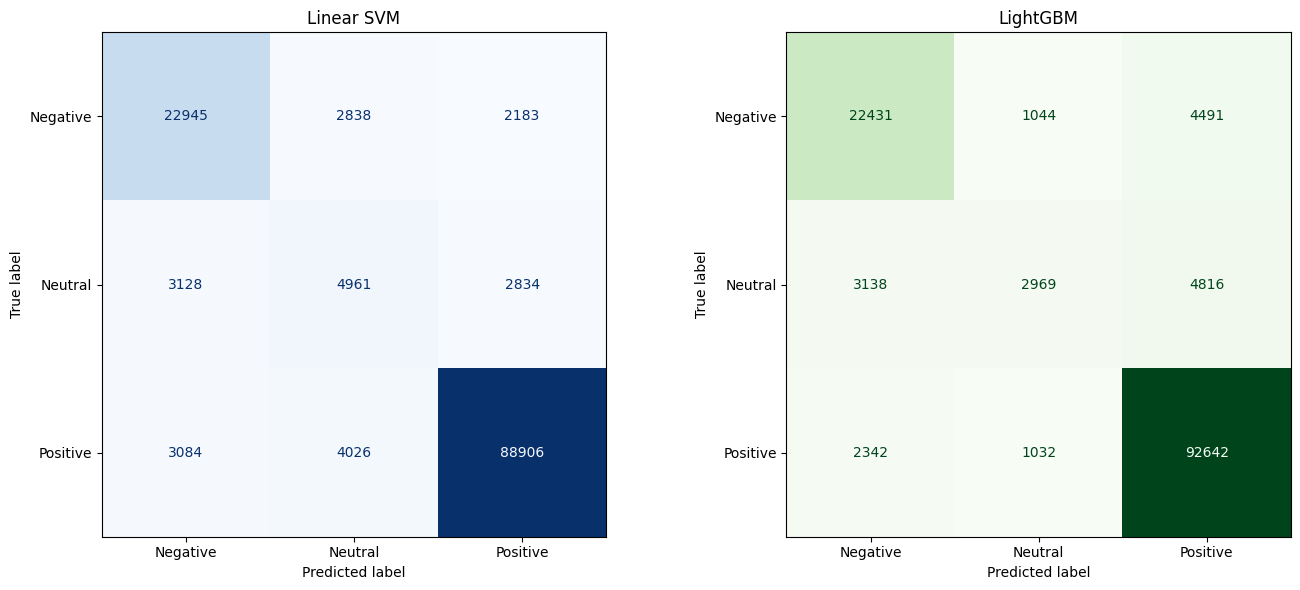

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear SVM
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    svm_pred,
    display_labels=le.classes_,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Linear SVM")

# LightGBM
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    lgbm_pred,
    display_labels=le.classes_,
    cmap="Greens",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("LightGBM")

plt.tight_layout()
plt.show()

## Best Model Evaluation

The two best-performing machine learning models, **Linear SVM** and **LightGBM**, were further evaluated using detailed classification reports and confusion matrices.

### Linear SVM

Linear SVM achieved the highest overall **Weighted F1-Score (86.81%)** while maintaining balanced performance across all three sentiment classes. The model demonstrated strong classification capability for Positive and Negative reviews and significantly outperformed LightGBM in identifying Neutral reviews. This balanced behaviour resulted in the highest Macro F1-Score among all evaluated models, indicating better generalization across minority and majority classes.

### LightGBM

LightGBM achieved the highest overall **Accuracy (87.50%)**, primarily due to its excellent performance in predicting the majority Positive class. However, the model showed limited ability to recognize Neutral reviews, leading to a substantially lower recall and Macro F1-Score compared to Linear SVM. The confusion matrix reveals that many Neutral reviews were incorrectly classified as Positive, indicating a bias toward the dominant class.

In [45]:
# Save Final Classical Model
joblib.dump(svm_model,"models/linear_svm_sentiment.pkl")

# Save Best Tree-Based Model
joblib.dump(lgbm_model,"models/lightgbm_sentiment.pkl"
)

# Save Label Encoder
joblib.dump(le,"models/label_encoder.pkl")

['models/label_encoder.pkl']

## Conclusion

Four classical machine learning algorithms were evaluated using multiple feature engineering strategies, including Original TF-IDF, Selected TF-IDF, TF-IDF with TruncatedSVD, and Hybrid Features.

Among all evaluated approaches, **Original TF-IDF consistently produced the strongest feature representation**, while additional feature selection and metadata integration did not provide a significant improvement.

Linear SVM achieved the highest Weighted F1-Score and Macro F1-Score, demonstrating the best balance across all sentiment classes. LightGBM achieved the highest overall accuracy but showed weaker performance on the minority Neutral class.

Based on the experimental results, **Linear SVM trained on the Original TF-IDF representation was selected as the final classical machine learning model** and will serve as the baseline for comparison with the Deep Learning and Transformer-based approaches developed in the subsequent notebooks.